# Automated Classification of Fetal Cardiotocograms for Antepartum Monitoring

## Importing Algorithm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import recall_score
import os
import joblib
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

## Data Analysis

In [2]:
data = pd.read_csv(r"C:\Users\USER\Desktop\saint martins\Fetal Cardiotocograms\fetal_health.csv")

In [3]:
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [4]:
data.tail()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
2121,140.0,0.000,0.000,0.007,0.0,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.0,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.0,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.0,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0
2125,142.0,0.002,0.002,0.008,0.0,0.0,0.0,74.0,0.4,36.0,...,117.0,159.0,2.0,1.0,145.0,143.0,145.0,1.0,0.0,1.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
baseline value                                            2126 non-null float64
accelerations                                             2126 non-null float64
fetal_movement                                            2126 non-null float64
uterine_contractions                                      2126 non-null float64
light_decelerations                                       2126 non-null float64
severe_decelerations                                      2126 non-null float64
prolongued_decelerations                                  2126 non-null float64
abnormal_short_term_variability                           2126 non-null float64
mean_value_of_short_term_variability                      2126 non-null float64
percentage_of_time_with_abnormal_long_term_variability    2126 non-null float64
mean_value_of_long_term_variability                       2126 non-null float64
histogram_wid

In [6]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [7]:
data.nunique()

baseline value                                             48
accelerations                                              20
fetal_movement                                            102
uterine_contractions                                       16
light_decelerations                                        16
severe_decelerations                                        2
prolongued_decelerations                                    6
abnormal_short_term_variability                            75
mean_value_of_short_term_variability                       57
percentage_of_time_with_abnormal_long_term_variability     87
mean_value_of_long_term_variability                       249
histogram_width                                           154
histogram_min                                             109
histogram_max                                              86
histogram_number_of_peaks                                  18
histogram_number_of_zeroes                                  9
histogra

## Data Preprocessing

In [8]:
data.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [9]:
data.duplicated().sum()

13

In [10]:
data = data.drop_duplicates()

In [11]:
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


## HeatMap

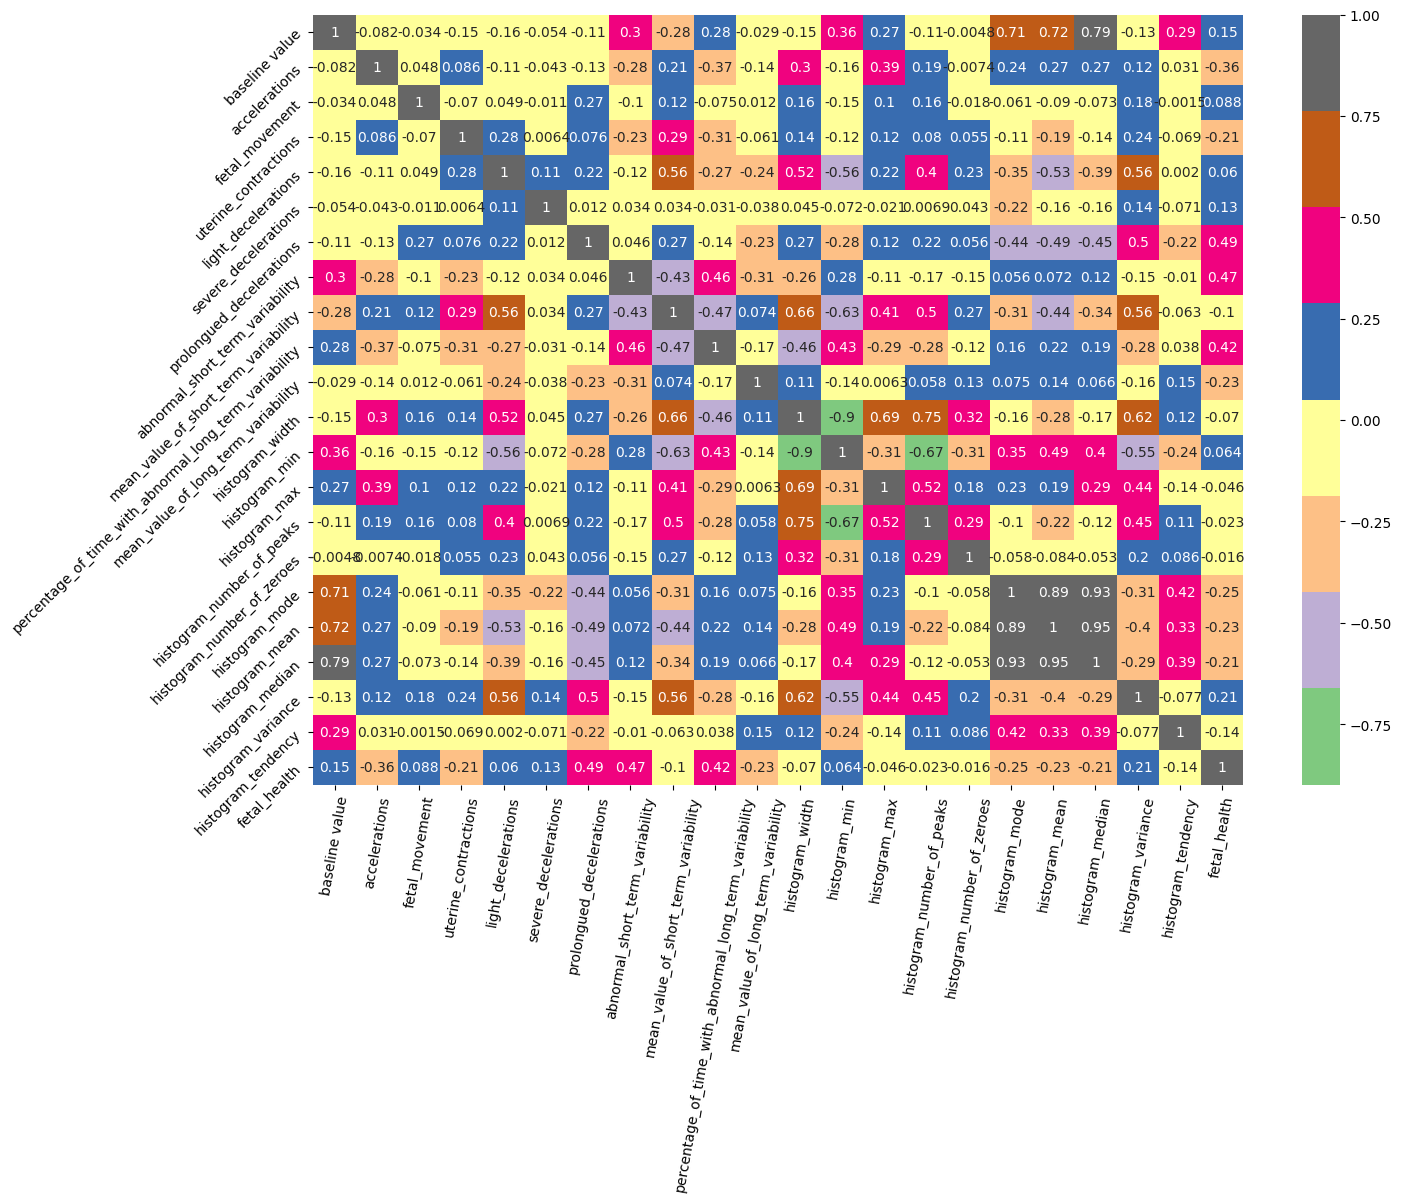

In [12]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),cmap = 'Accent',annot = True)
plt.xticks(rotation = 80)
plt.yticks(rotation = 45)
plt.show()

In [13]:
data = data.drop(['severe_decelerations'],axis = 1)
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,73.0,0.5,43.0,2.4,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,17.0,2.1,0.0,10.4,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,16.0,2.1,0.0,13.4,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,16.0,2.4,0.0,23.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,16.0,2.4,0.0,19.9,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,79.0,0.2,25.0,7.2,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,78.0,0.4,22.0,7.1,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,79.0,0.4,20.0,6.1,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,78.0,0.4,27.0,7.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [14]:
labels  = ['Normal','Suspect','Pathological']

## CountPlot

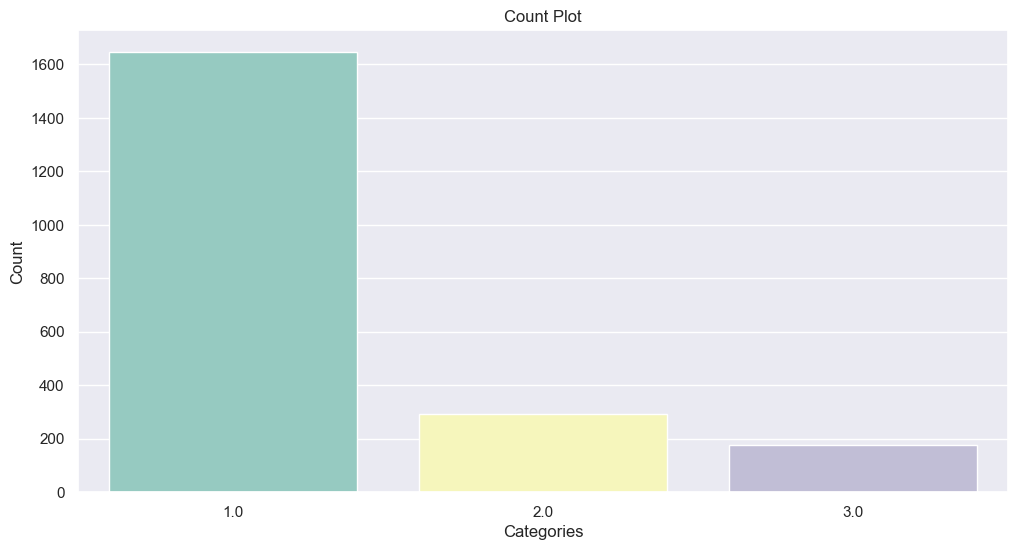

In [15]:
#labels = set(data['Attack_type'])
sns.set(style = "darkgrid") 
plt.figure(figsize = (12, 6)) 
ax = sns.countplot(x = data['fetal_health'], palette = "Set3",)
plt.title("Count Plot")  
plt.xlabel("Categories") 
plt.ylabel("Count") 
plt.show()

In [16]:
x = data.drop(['fetal_health'], axis = 1)
x

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.000,0.000,0.000,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.000,0.006,0.003,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.000,0.008,0.003,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.000,0.008,0.003,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,79.0,0.2,25.0,7.2,40.0,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,78.0,0.4,22.0,7.1,66.0,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,79.0,0.4,20.0,6.1,67.0,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,78.0,0.4,27.0,7.0,66.0,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0


In [17]:
y = data['fetal_health']
y

0       2.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
2121    2.0
2122    2.0
2123    2.0
2124    2.0
2125    1.0
Name: fetal_health, Length: 2113, dtype: float64

In [18]:
data = SMOTE(random_state=42)
x_resampled, y_resampled = data.fit_resample(x, y)
data

SMOTE(random_state=42)

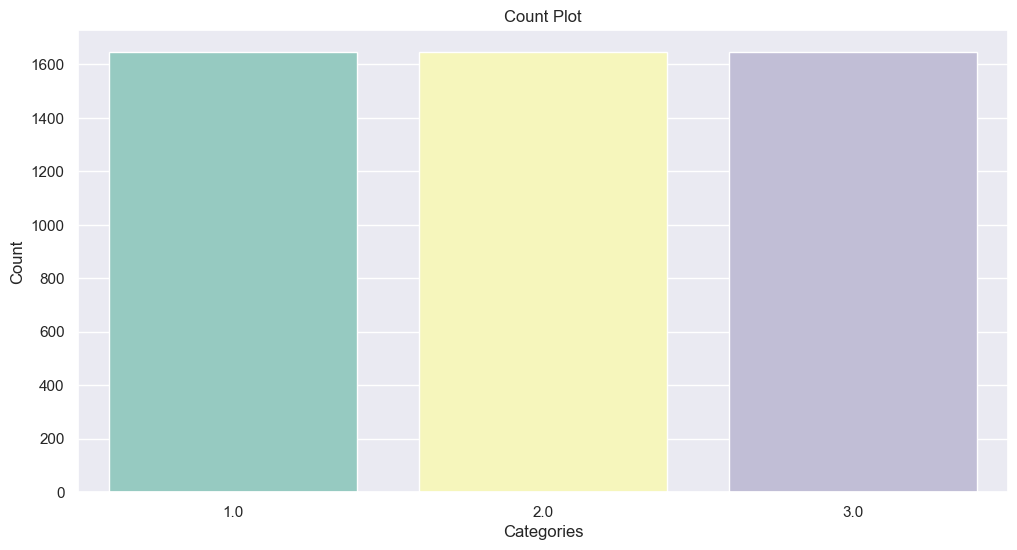

In [19]:
sns.set(style = "darkgrid") 
plt.figure(figsize = (12, 6)) 
ax = sns.countplot(x = y_resampled, palette = "Set3",)
plt.title("Count Plot")  
plt.xlabel("Categories") 
plt.ylabel("Count") 
plt.show()

## Data Splitting

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.30, random_state = 42)

In [21]:
x_train

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
1143,122.0,0.004,0.00,0.006,0.006,0.000,21.0,1.7,0.0,6.7,69.0,74.0,143.0,4.0,0.0,133.0,121.0,126.0,32.0,1.0
1290,115.0,0.003,0.00,0.009,0.001,0.000,21.0,1.7,0.0,10.7,83.0,85.0,168.0,2.0,0.0,129.0,122.0,125.0,19.0,0.0
1467,148.0,0.005,0.00,0.005,0.000,0.000,27.0,1.5,8.0,13.0,50.0,129.0,179.0,3.0,0.0,157.0,154.0,157.0,6.0,0.0
1077,134.0,0.002,0.00,0.010,0.005,0.000,26.0,1.8,10.0,15.1,82.0,82.0,164.0,5.0,0.0,147.0,133.0,137.0,40.0,1.0
15,130.0,0.006,0.38,0.004,0.004,0.001,19.0,2.3,0.0,8.7,107.0,67.0,174.0,3.0,0.0,134.0,127.0,133.0,43.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,132.0,0.007,0.00,0.010,0.011,0.000,56.0,2.8,0.0,0.0,116.0,70.0,186.0,5.0,0.0,106.0,115.0,133.0,113.0,-1.0
1104,122.0,0.000,0.00,0.003,0.000,0.000,21.0,2.2,0.0,17.4,39.0,104.0,143.0,4.0,2.0,129.0,126.0,128.0,4.0,0.0
1142,122.0,0.004,0.00,0.005,0.004,0.000,22.0,1.7,0.0,7.4,69.0,74.0,143.0,3.0,0.0,133.0,122.0,127.0,26.0,1.0
1306,138.0,0.002,0.00,0.007,0.005,0.000,32.0,1.1,16.0,6.6,78.0,97.0,175.0,5.0,0.0,145.0,139.0,144.0,16.0,0.0


In [22]:
y_train

1143    1.0
1290    1.0
1467    1.0
1077    1.0
15      1.0
       ... 
1651    1.0
1104    1.0
1142    1.0
1306    1.0
869     1.0
Name: fetal_health, Length: 1479, dtype: float64

In [23]:
x_test

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
601,144.0,0.002,0.010,0.002,0.000,0.000,76.0,0.6,0.0,11.8,54.0,126.0,180.0,2.0,0.0,156.0,153.0,155.0,5.0,0.0
2005,125.0,0.005,0.002,0.006,0.009,0.000,60.0,1.3,0.0,7.5,96.0,68.0,164.0,6.0,1.0,110.0,120.0,120.0,34.0,0.0
427,120.0,0.013,0.006,0.003,0.000,0.000,40.0,1.3,0.0,7.1,89.0,68.0,157.0,5.0,1.0,133.0,134.0,136.0,9.0,1.0
291,142.0,0.000,0.006,0.000,0.000,0.000,61.0,0.7,52.0,12.2,79.0,71.0,150.0,12.0,0.0,143.0,142.0,144.0,3.0,1.0
197,145.0,0.000,0.000,0.002,0.000,0.000,49.0,0.6,3.0,11.6,27.0,140.0,167.0,0.0,0.0,159.0,156.0,158.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,134.0,0.005,0.002,0.002,0.003,0.003,62.0,1.5,0.0,0.0,113.0,71.0,184.0,4.0,0.0,89.0,113.0,110.0,148.0,-1.0
948,142.0,0.006,0.000,0.001,0.000,0.000,45.0,0.8,1.0,11.1,47.0,113.0,160.0,4.0,2.0,150.0,148.0,151.0,4.0,1.0
523,158.0,0.010,0.029,0.003,0.000,0.000,41.0,0.8,0.0,0.0,45.0,153.0,198.0,2.0,0.0,186.0,180.0,183.0,11.0,1.0
817,152.0,0.000,0.000,0.002,0.000,0.000,60.0,0.4,57.0,8.0,36.0,128.0,164.0,2.0,0.0,160.0,157.0,160.0,2.0,1.0


In [24]:
y_test

601     2.0
2005    1.0
427     1.0
291     2.0
197     2.0
       ... 
1750    3.0
948     1.0
523     1.0
817     2.0
339     3.0
Name: fetal_health, Length: 634, dtype: float64

In [25]:
x_train.shape

(1479, 20)

In [26]:
y_train.shape

(1479,)

## Performance Evaluation

In [27]:
precision = []
recall = []
fscore = []
accuracy = []


def performance_metrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

## LGBM Classifier

LightGBM Classifier Accuracy    : 96.68769716088327
LightGBM Classifier Precision   : 94.9522611706156
LightGBM Classifier Recall      : 92.45442711430125
LightGBM Classifier FSCORE      : 93.5723937014322

 LightGBM Classifier classification report
               precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       507
     Suspect       0.82      0.94      0.88        79
Pathological       0.96      0.94      0.95        48

    accuracy                           0.97       634
   macro avg       0.92      0.95      0.94       634
weighted avg       0.97      0.97      0.97       634



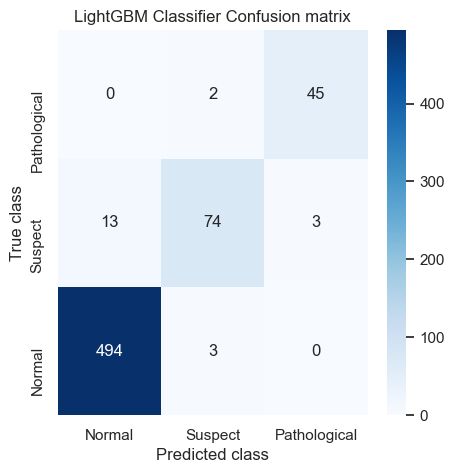

In [28]:
if os.path.exists('model/LightGBM_weights.pkl'):
    # Load the model from the pkl file
    classifier = joblib.load('model/LightGBM_weights.pkl')
else:
    # Train the classifier on the training data
    classifier = LGBMClassifier(random_state=4)  # You can adjust the parameters as needed
    classifier.fit(x_train, y_train)
    # Make predictions on the test data
    predict = classifier.predict(x_test)
    # Save the model weights to a pkl file
    joblib.dump(classifier, 'model/LightGBM_weights.pkl')
    print("LightGBM classifier model trained and model weights saved.")
    performance_metrics("LightGBM Classifier", predict, y_test)

predict = classifier.predict(x_test)
performance_metrics("LightGBM Classifier", predict, y_test)

## Bagging Classifier

Bagging Classifier Accuracy    : 94.95268138801262
Bagging Classifier Precision   : 92.3547030069127
Bagging Classifier Recall      : 91.11006464317822
Bagging Classifier FSCORE      : 91.70916407795842

 Bagging Classifier classification report
               precision    recall  f1-score   support

      Normal       0.98      0.97      0.97       502
     Suspect       0.80      0.85      0.82        85
Pathological       0.96      0.96      0.96        47

    accuracy                           0.95       634
   macro avg       0.91      0.92      0.92       634
weighted avg       0.95      0.95      0.95       634



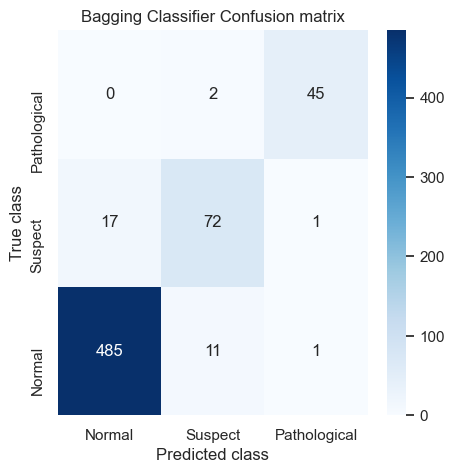

In [29]:
if os.path.exists('model/BaggingClassifier_weights.pkl'):
    # Load the model from the pkl file
    classifier = joblib.load('model/BaggingClassifier_weights.pkl')
else:
    # Train the classifier on the training data
    base_estimator = DecisionTreeClassifier(random_state=4)  # Base estimator
    classifier = BaggingClassifier(base_estimator=base_estimator, random_state=4, n_estimators=50)  # You can adjust the parameters as needed
    classifier.fit(x_train, y_train)
    # Save the model weights to a pkl file
    joblib.dump(classifier, 'model/BaggingClassifier_weights.pkl')
    print("Bagging Classifier model trained and model weights saved.")

# Make predictions on the test data
y_predict = classifier.predict(x_test)
performance_metrics("Bagging Classifier", y_predict, y_test)

In [31]:
test = pd.read_csv(r"test.csv")
test.head(1)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,148.0,0.0,0.0,0.006,0.0,0.0,0.0,51.0,0.5,62.0,...,8.0,155.0,163.0,1.0,0.0,160.0,159.0,161.0,0.0,0.0


In [32]:
test = test.drop(['severe_decelerations'],axis = 1)
test.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,148.0,0.0,0.000,0.006,0.000,0.0,51.0,0.5,62.0,4.5,8.0,155.0,163.0,1.0,0.0,160.0,159.0,161.0,0.0,0.0
1,145.0,0.0,0.000,0.001,0.001,0.0,62.0,0.5,8.0,10.1,87.0,70.0,157.0,1.0,1.0,148.0,145.0,148.0,4.0,1.0
2,144.0,0.0,0.019,0.000,0.000,0.0,76.0,0.4,61.0,10.6,81.0,71.0,152.0,3.0,0.0,145.0,144.0,146.0,2.0,1.0
3,146.0,0.0,0.004,0.000,0.000,0.0,79.0,0.2,56.0,4.3,12.0,137.0,149.0,1.0,0.0,144.0,143.0,145.0,0.0,0.0
4,145.0,0.0,0.000,0.001,0.000,0.0,50.0,0.7,17.0,7.3,42.0,125.0,167.0,8.0,0.0,153.0,154.0,155.0,2.0,1.0


In [33]:
x_test.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency'],
      dtype='object')

In [34]:
test.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency'],
      dtype='object')

In [35]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 20 columns):
baseline value                                            60 non-null float64
accelerations                                             60 non-null float64
fetal_movement                                            60 non-null float64
uterine_contractions                                      60 non-null float64
light_decelerations                                       60 non-null float64
prolongued_decelerations                                  60 non-null float64
abnormal_short_term_variability                           60 non-null float64
mean_value_of_short_term_variability                      60 non-null float64
percentage_of_time_with_abnormal_long_term_variability    60 non-null float64
mean_value_of_long_term_variability                       60 non-null float64
histogram_width                                           60 non-null float64
histogram_min                          

In [36]:
predict = classifier.predict(test)
predict

array([1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3.])

In [37]:
# Define labels
A = 'Normal'
B = 'Suspect'
C = 'Pathological'

# Load the test data
#test = pd.read_csv(r"test.csv")

# Load the pre-trained classifier
classifier = joblib.load('model/LightGBM_weights.pkl')

# Make predictions
predict = classifier.predict(test)

# Print the results
for i in range(len(predict)):
    if predict[i] == 1:
        print("{}: {}".format(test.iloc[i, :].values, A))
    elif predict[i] == 2:
        print("{}: {}".format(test.iloc[i, :].values, B))
    elif predict[i] == 3:
        print("{}: {}".format(test.iloc[i, :].values, C)) 

[1.48e+02 0.00e+00 0.00e+00 6.00e-03 0.00e+00 0.00e+00 5.10e+01 5.00e-01
 6.20e+01 4.50e+00 8.00e+00 1.55e+02 1.63e+02 1.00e+00 0.00e+00 1.60e+02
 1.59e+02 1.61e+02 0.00e+00 0.00e+00]: Suspect
[1.45e+02 0.00e+00 0.00e+00 1.00e-03 1.00e-03 0.00e+00 6.20e+01 5.00e-01
 8.00e+00 1.01e+01 8.70e+01 7.00e+01 1.57e+02 1.00e+00 1.00e+00 1.48e+02
 1.45e+02 1.48e+02 4.00e+00 1.00e+00]: Suspect
[1.44e+02 0.00e+00 1.90e-02 0.00e+00 0.00e+00 0.00e+00 7.60e+01 4.00e-01
 6.10e+01 1.06e+01 8.10e+01 7.10e+01 1.52e+02 3.00e+00 0.00e+00 1.45e+02
 1.44e+02 1.46e+02 2.00e+00 1.00e+00]: Suspect
[1.46e+02 0.00e+00 4.00e-03 0.00e+00 0.00e+00 0.00e+00 7.90e+01 2.00e-01
 5.60e+01 4.30e+00 1.20e+01 1.37e+02 1.49e+02 1.00e+00 0.00e+00 1.44e+02
 1.43e+02 1.45e+02 0.00e+00 0.00e+00]: Suspect
[1.45e+02 0.00e+00 0.00e+00 1.00e-03 0.00e+00 0.00e+00 5.00e+01 7.00e-01
 1.70e+01 7.30e+00 4.20e+01 1.25e+02 1.67e+02 8.00e+00 0.00e+00 1.53e+02
 1.54e+02 1.55e+02 2.00e+00 1.00e+00]: Suspect
[1.54e+02 0.00e+00 0.00e+00 4.00e-0